# MATH313 HW8 Tommy Pett

# Question 1 
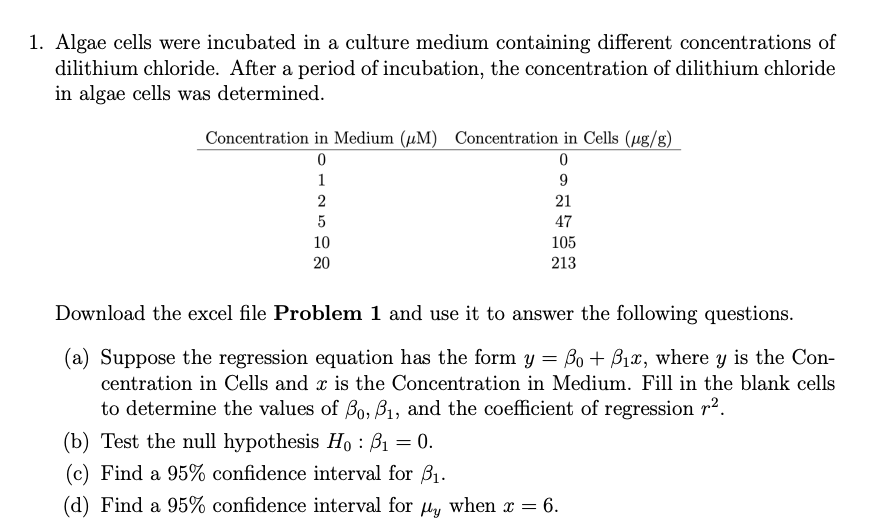

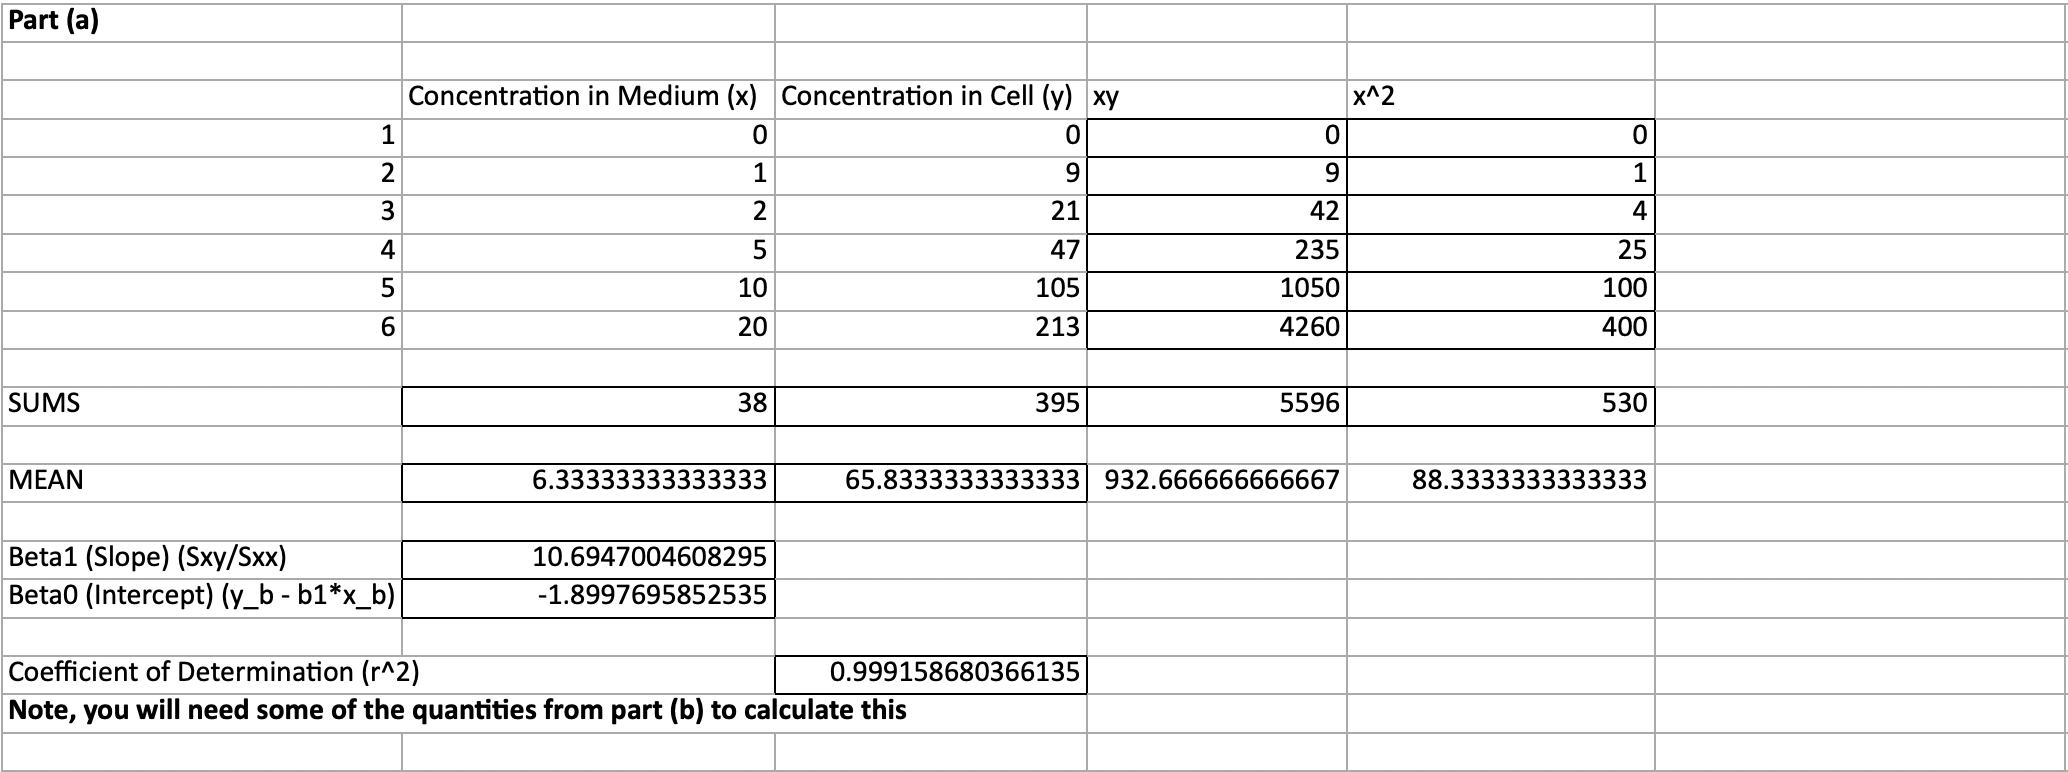
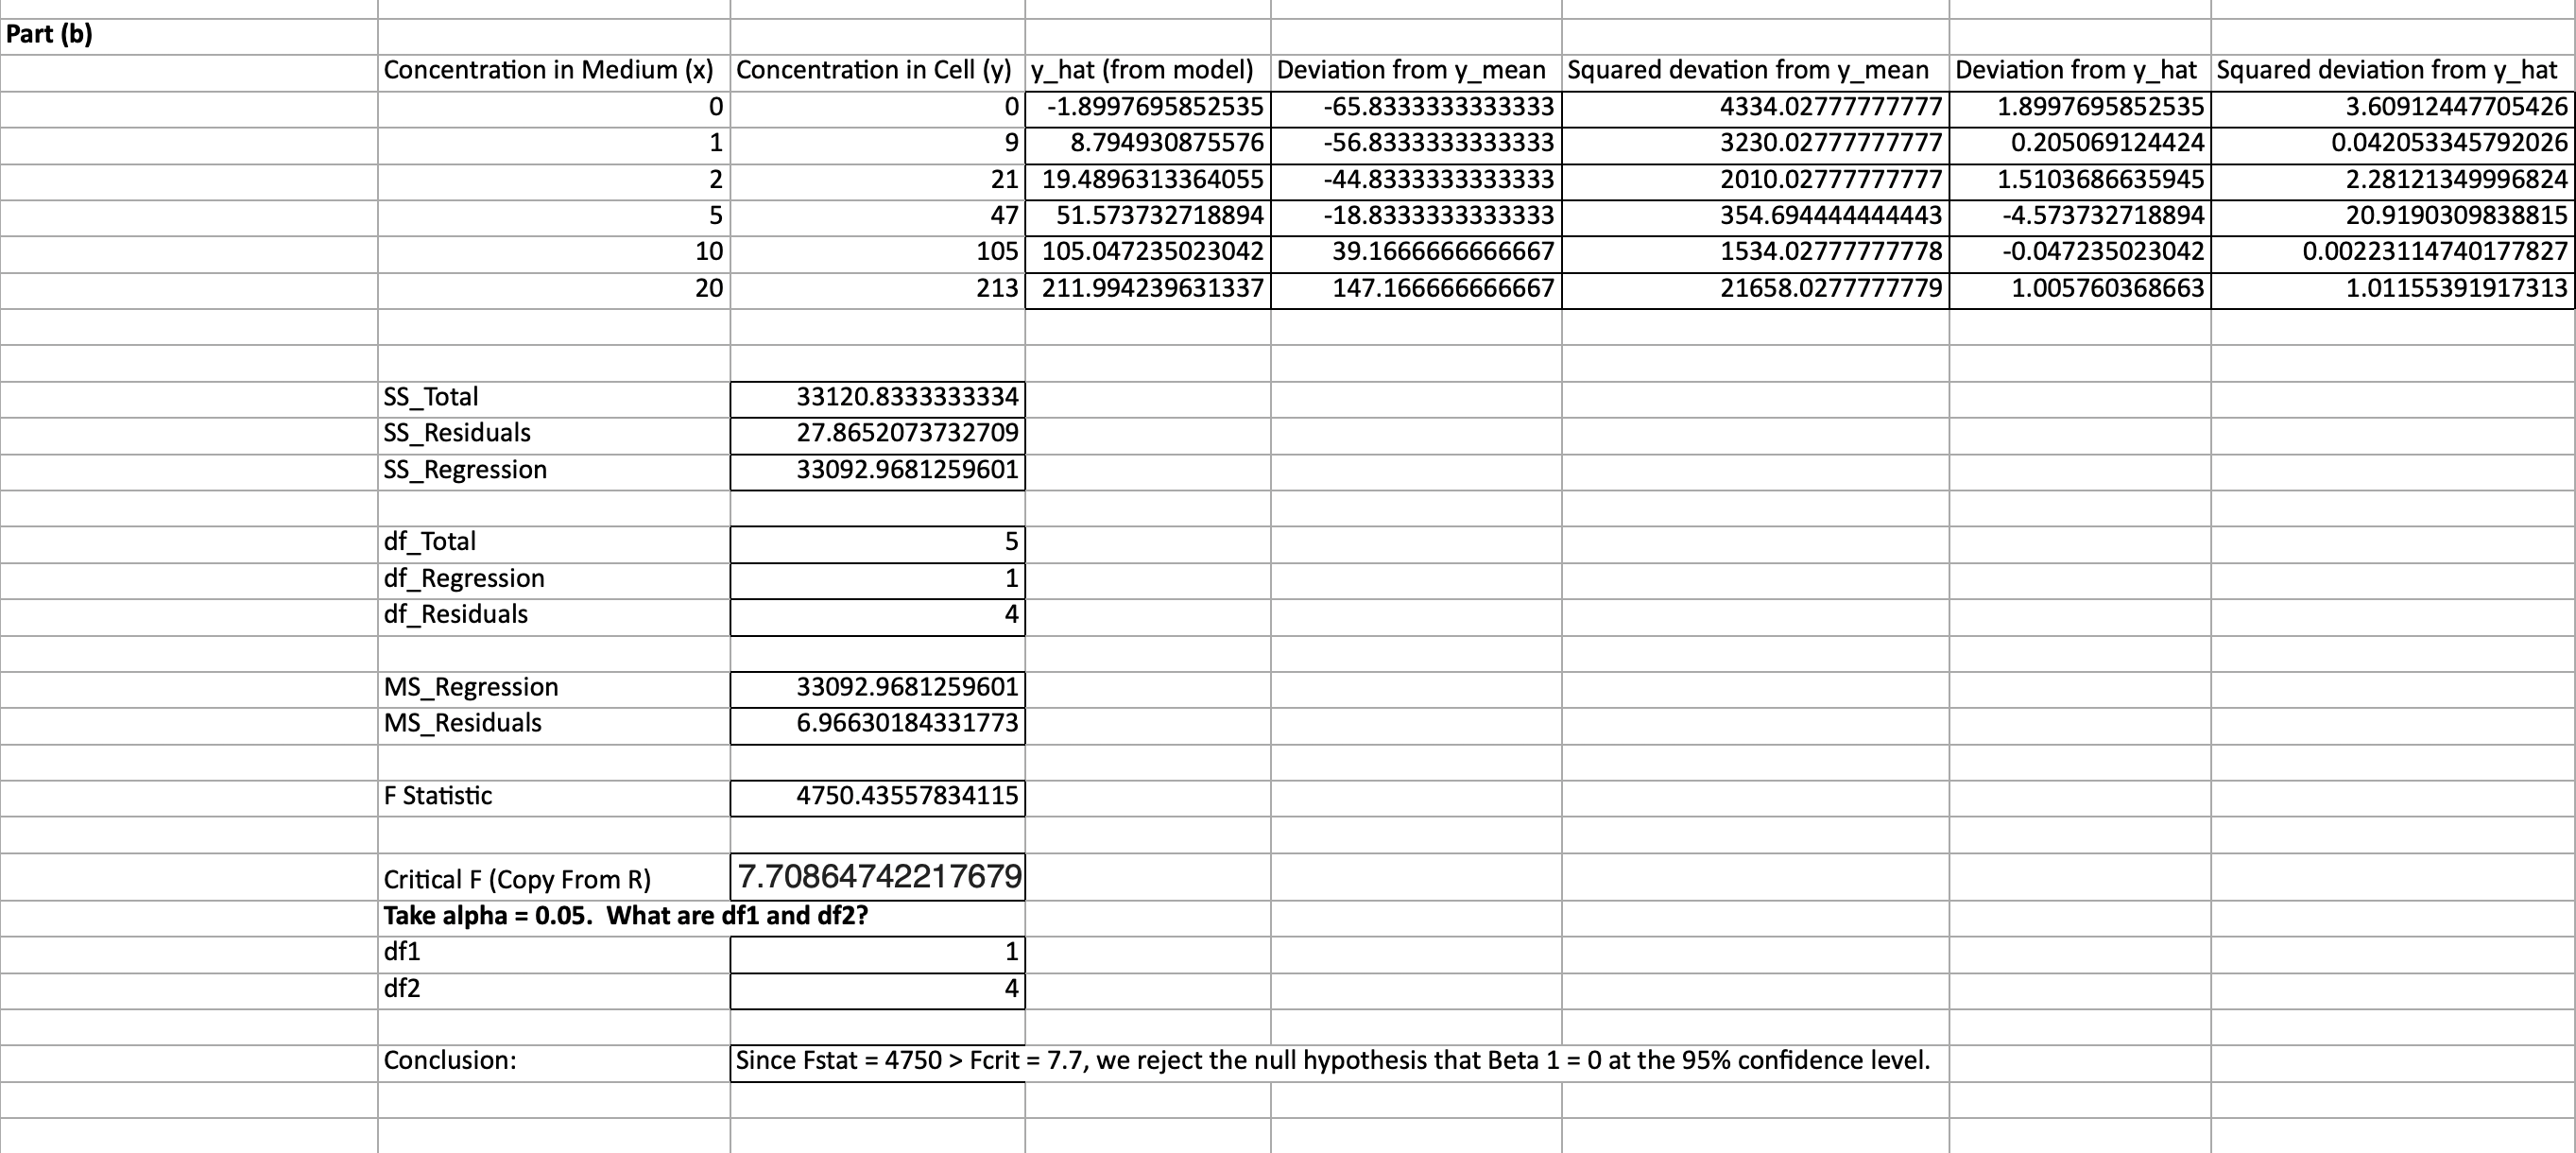
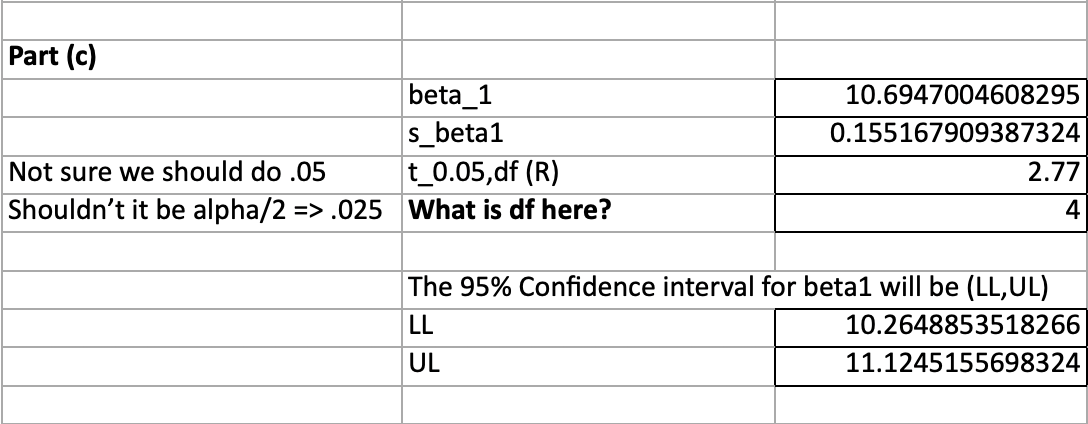
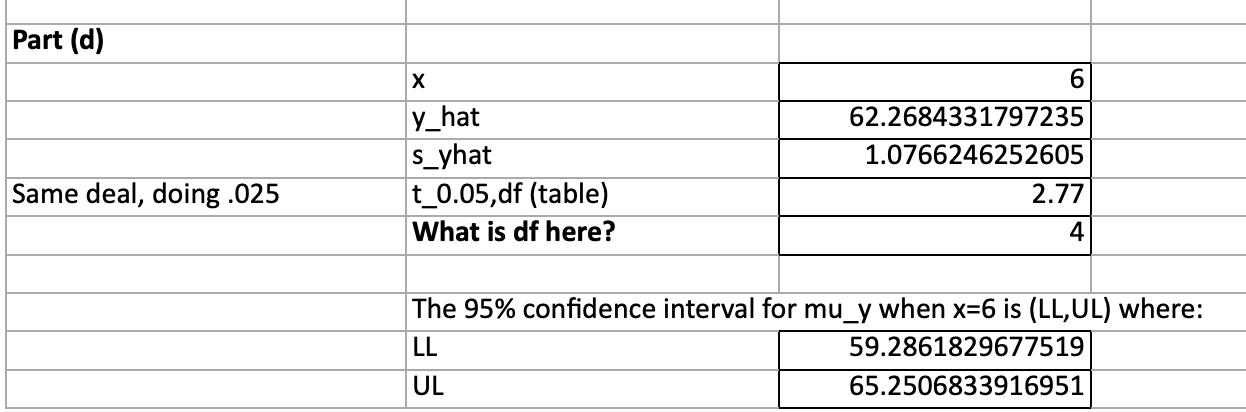

In [3]:
qf(.05, 1, 4, lower.tail=F)
qt(.025, 4, lower.tail=F)

[1] 7.708647

[1] 2.776445

# Question 2 
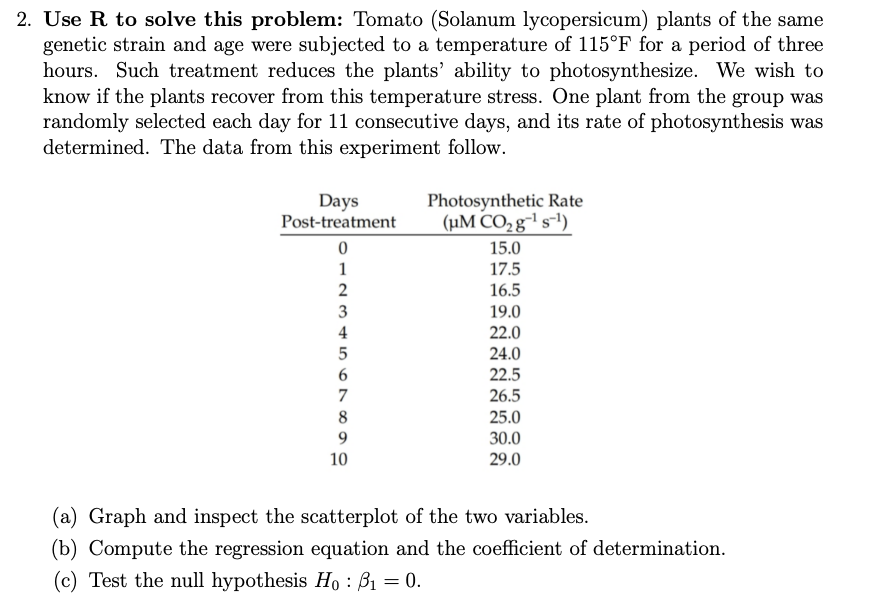

Correlation coefficient (r): 0.9656 



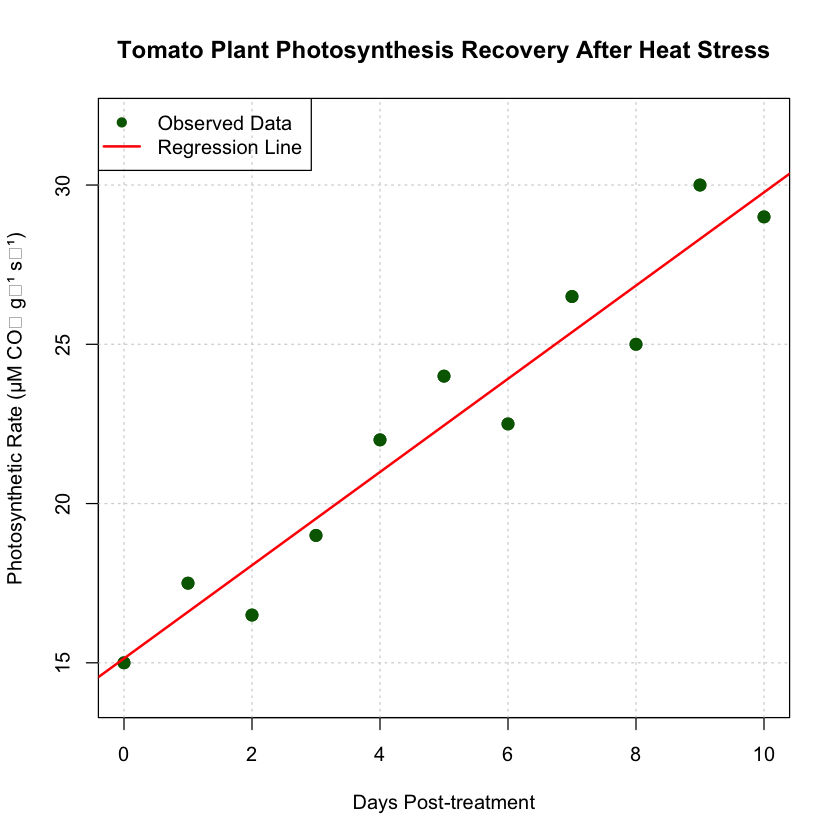

In [13]:
# Part a-b
days_post_treatment <- c(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10)
photosynthetic_rate <- c(15.0, 17.5, 16.5, 19.0, 22.0, 24.0, 22.5, 26.5, 25.0, 30.0, 29.0)
plant_data <- data.frame(days = days_post_treatment, rate = photosynthetic_rate)
plot(days_post_treatment, photosynthetic_rate,
     main = "Tomato Plant Photosynthesis Recovery After Heat Stress",
     xlab = "Days Post-treatment", 
     ylab = "Photosynthetic Rate (μM CO₂ g⁻¹ s⁻¹)",
     pch = 19, 
     col = "darkgreen", 
     cex = 1.3,
     xlim = c(0, 10),
     ylim = c(14, 32))
grid(col = "lightgray", lty = "dotted")
points(days_post_treatment, photosynthetic_rate, pch = 19, col = "darkgreen", cex = 1.3)

model <- lm(photosynthetic_rate ~ days_post_treatment)
coefficients <- coef(model)
beta_0 <- coefficients[1]  # Intercept 
beta_1 <- coefficients[2]  # Slope 
r_squared <- summary(model)$r.squared
adj_r_squared <- summary(model)$adj.r.squared
abline(model, col = "red", lwd = 2)
legend("topleft", 
       legend = c("Observed Data", "Regression Line"), 
       col = c("darkgreen", "red"), 
       pch = c(19, NA), 
       lty = c(NA, 1), 
       lwd = c(NA, 2))
correlation <- cor(days_post_treatment, photosynthetic_rate)
cat("Correlation coefficient (r):", round(correlation, 4), "\n\n")

In [112]:
# Part c 
cat("H0: B1 = 0 (no linear relationship - no recovery effect)\n")
cat("H1: B1 /= 0 (significant linear relationship - recovery occurs)\n")
cat("Significance level: α = 0.05\n\n")


summary_stats <- summary(model)
t_statistic <- summary_stats$coefficients[2, 3]  # t-value for β₁
p_value <- summary_stats$coefficients[2, 4]      # p-value for β₁
std_error <- summary_stats$coefficients[2, 2]    # Standard error of β₁
n <- length(days_post_treatment)
df <- n - 2
alpha <- 0.05
t_critical <- qt(alpha/2, df, lower.tail=F)

if (abs(t_statistic) > t_critical) {
    cat("Since |t| =", round(abs(t_statistic), 4), ">", round(t_critical, 4), ", we reject H0\n")
    cat("p-value =", format(p_value, scientific = TRUE, digits = 4), "< 0.05\n")
    cat("There is statistically significant evidence at the 95% CI level to conclude that tomato plants recover their photosynthetic capacity over time following heat stress.\n")
} else {
    cat("Since |t| =", round(abs(t_statistic), 4), "≤", round(t_critical, 4), ", we fail to reject H0\n")
    cat("p-value =", format(p_value, digits = 4), "≥ 0.05\n")
    cat("There is not sufficient statistical evidence at the 95 CI level to conclude that tomato plants recover their photosynthetic capacity over time.\n")
}

H0: B1 = 0 (no linear relationship - no recovery effect)
H1: B1 /= 0 (significant linear relationship - recovery occurs)
Significance level: α = 0.05

Since |t| = 11.1425 > 2.2622 , we reject H0
p-value = 1.444e-06 < 0.05
There is statistically significant evidence at the 95% CI level to conclude that tomato plants recover their photosynthetic capacity over time following heat stress.


# Question 3 
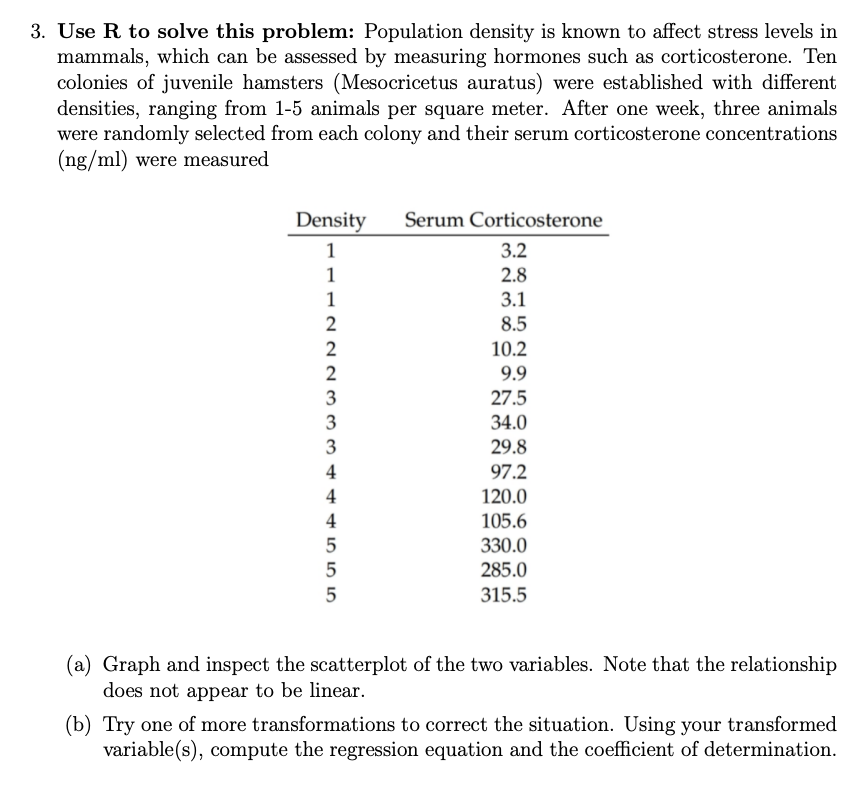

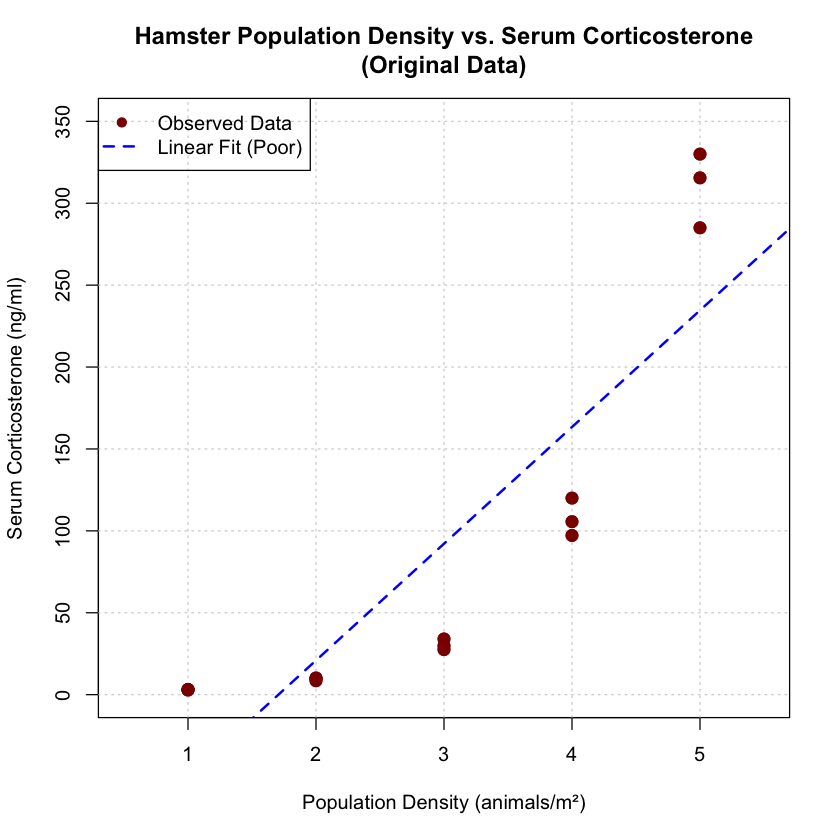

In [21]:
# Part a 
density <- c(1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 5)
corticosterone <- c(3.2, 2.8, 3.1, 8.5, 10.2, 9.9, 27.5, 34.0, 29.8, 97.2, 120.0, 105.6, 330.0, 285.0, 315.5)
hamster_data <- data.frame(density = density, corticosterone = corticosterone)
plot(density, corticosterone,
     main = "Hamster Population Density vs. Serum Corticosterone\n(Original Data)",
     xlab = "Population Density (animals/m²)", 
     ylab = "Serum Corticosterone (ng/ml)",
     pch = 19, 
     col = "darkred", 
     cex = 1.3,
     xlim = c(0.5, 5.5),
     ylim = c(0, 350))
grid(col = "lightgray", lty = "dotted")
points(density, corticosterone, pch = 19, col = "darkred", cex = 1.3)
initial_model <- lm(corticosterone ~ density)
abline(initial_model, col = "blue", lwd = 2, lty = 2)
legend("topleft", 
       legend = c("Observed Data", "Linear Fit (Poor)"), 
       col = c("darkred", "blue"), 
       pch = c(19, NA), 
       lty = c(NA, 2), 
       lwd = c(NA, 2))

In [89]:
# Part b 

# 1. Natural log transformation of y
log_corticosterone <- log(corticosterone)
model_log_y <- lm(log_corticosterone ~ density)
r2_log_y <- summary(model_log_y)$r.squared

# 2. Square root transformation of y  
sqrt_corticosterone <- sqrt(corticosterone)
model_sqrt_y <- lm(sqrt_corticosterone ~ density)
r2_sqrt_y <- summary(model_sqrt_y)$r.squared

# 3. Log10 transformation of y
log10_corticosterone <- log10(corticosterone)
model_log10_y <- lm(log10_corticosterone ~ density)
r2_log10_y <- summary(model_log10_y)$r.squared

# 4. Inverse transformation (1/y)
inverse_corticosterone <- 1 / corticosterone
model_inverse_y <- lm(inverse_corticosterone ~ density)
r2_inverse_y <- summary(model_inverse_y)$r.squared

# Compare R² values
cat("Transformation Comparison (R² values):\n")
cat("Original (no transformation):", round(summary(initial_model)$r.squared, 4), "\n")
cat("Natural log(y):", round(r2_log_y, 4), "\n")
cat("Square root(y):", round(r2_sqrt_y, 4), "\n")
cat("Log10(y):", round(r2_log10_y, 4), "\n")
cat("Inverse(1/y):", round(r2_inverse_y, 4), "\n\n")

# Determine best transformation
transformations <- c("Original", "log(y)", "sqrt(y)", "log10(y)", "1/y")
r2_values <- c(summary(initial_model)$r.squared, r2_log_y, r2_sqrt_y, r2_log10_y, r2_inverse_y)
best_transformation <- transformations[which.max(r2_values)]
best_r2 <- max(r2_values)

cat("BEST TRANSFORMATION:", best_transformation, "with R² =", round(best_r2, 4), "\n\n")


Transformation Comparison (R² values):
Original (no transformation): 0.7597 
Natural log(y): 0.9974 
Square root(y): 0.9091 
Log10(y): 0.9974 
Inverse(1/y): 0.7454 

BEST TRANSFORMATION: log(y) with R² = 0.9974 



In [97]:
# Using log(y) ==> get regression equation in terms of y by taking exp() both sides 
coefficients_log <- coef(model_log_y)
beta_0_log <- coefficients_log[1]
beta_1_log <- coefficients_log[2]  
r_squared_log <- summary(model_log_y)$r.squared
cat("corticosterone =", round(exp(beta_0_log), 4), "× e^(", round(beta_1_log, 4), "× density)\n")
cat("R² =", round(r_squared_log, 6), "\n")

corticosterone = 0.9352 × e^( 1.1677 × density)
R² = 0.997381 


# Question 4
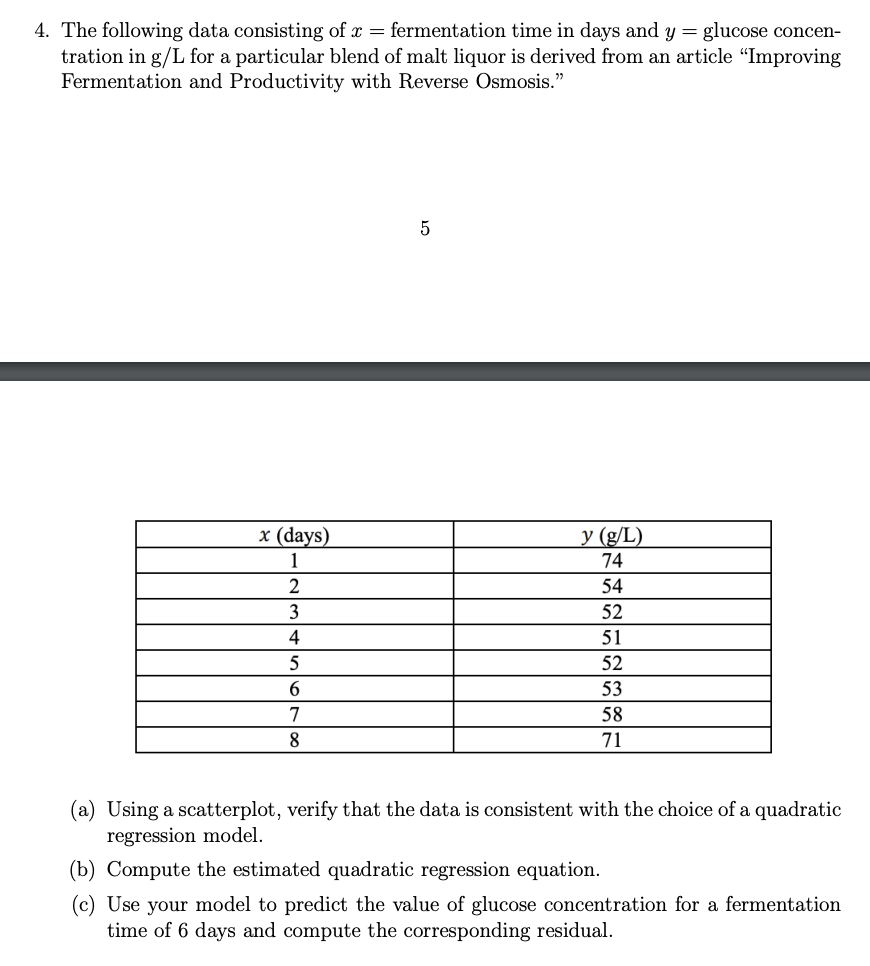

R² = 9.1e-05 


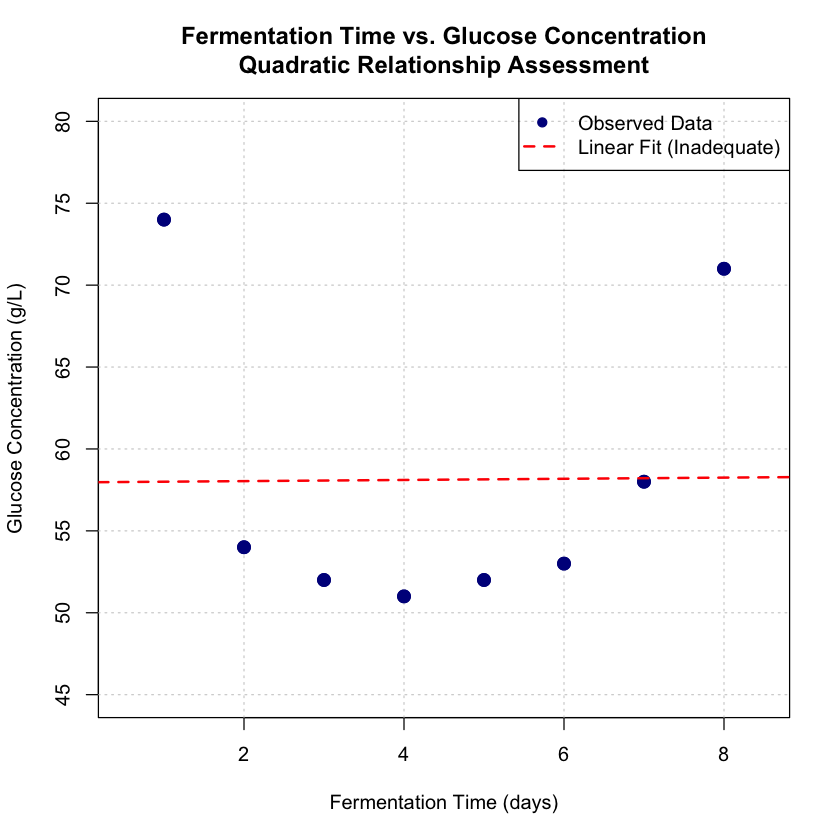

In [85]:
# Part a 
fermentation_time <- c(1, 2, 3, 4, 5, 6, 7, 8)
glucose_concentration <- c(74, 54, 52, 51, 52, 53, 58, 71)
fermentation_data <- data.frame(
    time = fermentation_time,
    glucose = glucose_concentration
)
plot(fermentation_time, glucose_concentration,
     main = "Fermentation Time vs. Glucose Concentration\nQuadratic Relationship Assessment",
     xlab = "Fermentation Time (days)", 
     ylab = "Glucose Concentration (g/L)",
     pch = 19, 
     col = "darkblue", 
     cex = 1.4,
     xlim = c(0.5, 8.5),
     ylim = c(45, 80))
grid(col = "lightgray", lty = "dotted")
points(fermentation_time, glucose_concentration, pch = 19, col = "darkblue", cex = 1.4)
linear_model <- lm(glucose ~ time, data = fermentation_data)
r_squared_linear <- summary(linear_model)$r.squared
abline(linear_model, col = "red", lwd = 2, lty = 2)
legend("topright", 
       legend = c("Observed Data", "Linear Fit (Inadequate)"), 
       col = c("darkblue", "red"), 
       pch = c(19, NA), 
       lty = c(NA, 2), 
       lwd = c(NA, 2))
cat("R² =", round(r_squared_linear, 6), "\n")

ŷ = B0 + B1x + B2x²
ŷ = 84.48214 + -15.875 x + 1.767857 x²
R² = 0.894751 


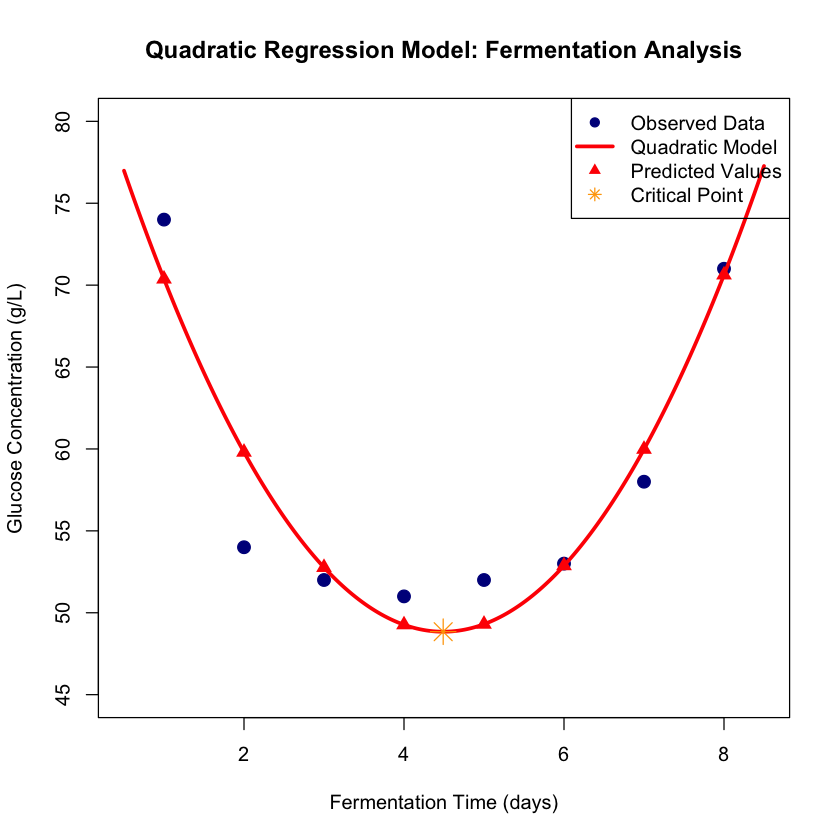

In [111]:
# Part b 
quadratic_model <- lm(glucose ~ time + I(time^2), data = fermentation_data)
coefficients_quad <- coef(quadratic_model)
beta_0 <- coefficients_quad[1]  # Intercept
beta_1 <- coefficients_quad[2]  # Linear coefficient  
beta_2 <- coefficients_quad[3]  # Quadratic coefficient
r_squared <- summary(quadratic_model)$r.squared
residual_std_error <- summary(quadratic_model)$sigma
critical_point_x <- -beta_1 / (2 * beta_2)
critical_point_y <- beta_0 + beta_1 * critical_point_x + beta_2 * critical_point_x^2


cat("ŷ = B0 + B1x + B2x²\n")
cat("ŷ =", round(beta_0, 6), "+", round(beta_1, 6), "x +", round(beta_2, 6), "x²\n")
cat("R² =", round(r_squared, 6), "\n")


plot(fermentation_time, glucose_concentration,
     main = "Quadratic Regression Model: Fermentation Analysis",
     xlab = "Fermentation Time (days)", 
     ylab = "Glucose Concentration (g/L)",
     pch = 19, 
     col = "darkblue", 
     cex = 1.4,
     xlim = c(0.5, 8.5),
     ylim = c(45, 80))
time_smooth <- seq(0.5, 8.5, length.out = 200)
glucose_predicted_smooth <- predict(quadratic_model, newdata = data.frame(time = time_smooth))
lines(time_smooth, glucose_predicted_smooth, col = "red", lwd = 3)
glucose_predicted <- predict(quadratic_model)
points(fermentation_time, glucose_predicted, col = "red", pch = 17, cex = 1.3)
points(critical_point_x, critical_point_y, col = "orange", pch = 8, cex = 2)
legend("topright", 
       legend = c("Observed Data", "Quadratic Model", "Predicted Values", "Critical Point"), 
       col = c("darkblue", "red", "red", "orange"), 
       pch = c(19, NA, 17, 8), 
       lty = c(NA, 1, NA, NA), 
       lwd = c(NA, 3, NA, NA))

In [59]:
# Part c 
target_time <- 6
predicted_glucose_6 <- predict(quadratic_model, newdata = data.frame(time = target_time))
actual_glucose_6 <- fermentation_data$glucose[fermentation_data$time == target_time]
residual_6 <- actual_glucose_6 - predicted_glucose_6

# Display prediction results
cat("Predicted glucose concentration: ŷ₆ =", round(predicted_glucose_6, 6), "g/L\n")
cat("Actual observed concentration: y₆ =", actual_glucose_6, "g/L\n")
cat("Residual: e₆ = y₆ - ŷ₆ =", round(residual_6, 6), "g/L\n")
if (residual_6 > 0) {
    cat("The model slightly underestimates the glucose concentration at 6 days by", abs(round(residual_6, 6)), "g/L\n\n")
} else {
    cat("The model slightly overestimates the glucose concentration at 6 days by", abs(round(residual_6, 6)), "g/L\n\n")
}

Predicted glucose concentration: ŷ₆ = 52.875 g/L
Actual observed concentration: y₆ = 53 g/L
Residual: e₆ = y₆ - ŷ₆ = 0.125 g/L
The model slightly underestimates the glucose concentration at 6 days by 0.125 g/L



# Question 5
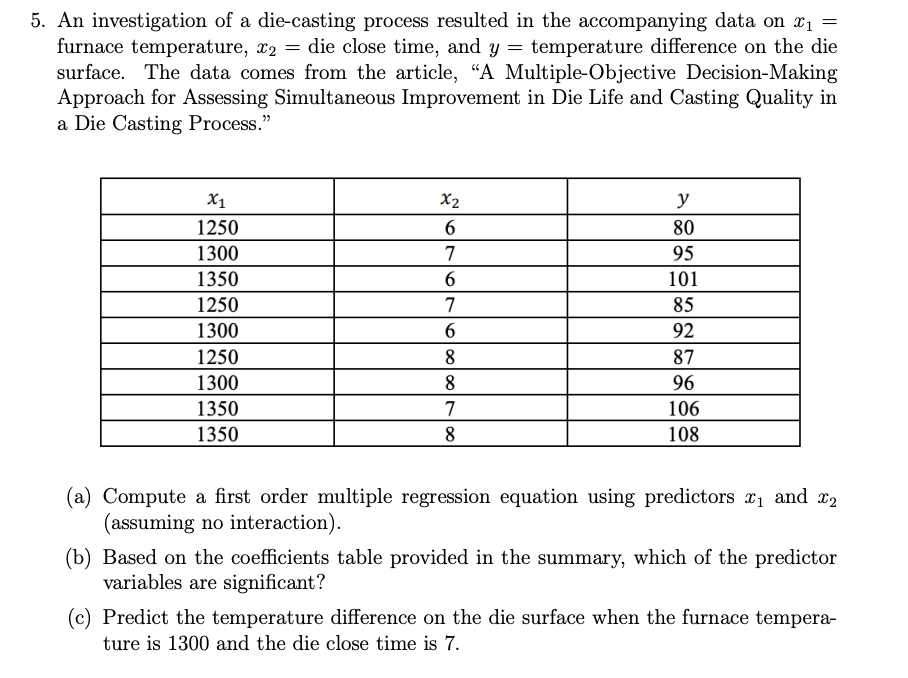

In [110]:
# Part a-b
furnace_temp <- c(1250, 1300, 1350, 1250, 1300, 1250, 1300, 1350, 1350)
die_close_time <- c(6, 7, 6, 7, 6, 8, 8, 7, 8)
temp_difference <- c(80, 95, 101, 85, 92, 87, 96, 106, 108)
die_casting_data <- data.frame(
    x1 = furnace_temp,
    x2 = die_close_time,
    y = temp_difference
)
multiple_model <- lm(y ~ x1 + x2, data = die_casting_data)
coefficients_multi <- coef(multiple_model)
beta_0 <- coefficients_multi[1] 
beta_1 <- coefficients_multi[2]  
beta_2 <- coefficients_multi[3]  
r_squared <- summary(multiple_model)$r.squared
adj_r_squared <- summary(multiple_model)$adj.r.squared
residual_std_error <- summary(multiple_model)$sigma
f_statistic <- summary(multiple_model)$fstatistic[1]
f_p_value <- pf(f_statistic, 2, nrow(die_casting_data)-3, lower.tail = F)

cat("ŷ = B0 + B1x1 + B2x2\n")
cat("ŷ =", round(beta_0, 6), "+", round(beta_1, 6), "x1 +", round(beta_2, 6), "x2\n")
cat("where x1 = furnace temp & x2 = die close time\n\n\n")
summary(multiple_model)

ŷ = B0 + B1x1 + B2x2
ŷ = -199.5556 + 0.21 x1 + 3 x2
where x1 = furnace temp & x2 = die close time





Call:
lm(formula = y ~ x1 + x2, data = die_casting_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.44444 -0.94444  0.05556  0.55556  1.05556 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -1.996e+02  1.164e+01 -17.143 2.52e-06 ***
x1           2.100e-01  8.642e-03  24.299 3.19e-07 ***
x2           3.000e+00  4.321e-01   6.943 0.000443 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.058 on 6 degrees of freedom
Multiple R-squared:  0.9907,	Adjusted R-squared:  0.9876 
F-statistic: 319.3 on 2 and 6 DF,  p-value: 8.064e-07


- both x1 and x2 have extremely small p-values so they are significant 

In [107]:
# Part c 
x1_pred <- 1300  # Furnace temperature
x2_pred <- 7     # Die close time

predicted_temp_diff <- predict(multiple_model, newdata = data.frame(x1 = x1_pred, x2 = x2_pred))
predicted_manual <- beta_0 + beta_1 * x1_pred + beta_2 * x2_pred

cat("ŷ = B0 + B1(1300) + B2(7)\n")
cat("ŷ =", round(beta_0, 6), "+", round(beta_1, 6), "(1300) +", round(beta_2, 6), "(7)\n")
cat("ŷ =", round(beta_0, 6), "+", round(beta_1 * x1_pred, 6), "+", round(beta_2 * x2_pred, 6), "\n")
cat("ŷ =", round(predicted_temp_diff, 6), "\n\n")

ŷ = B0 + B1(1300) + B2(7)
ŷ = -199.5556 + 0.21 (1300) + 3 (7)
ŷ = -199.5556 + 273 + 21 
ŷ = 94.44444 



# Question 6
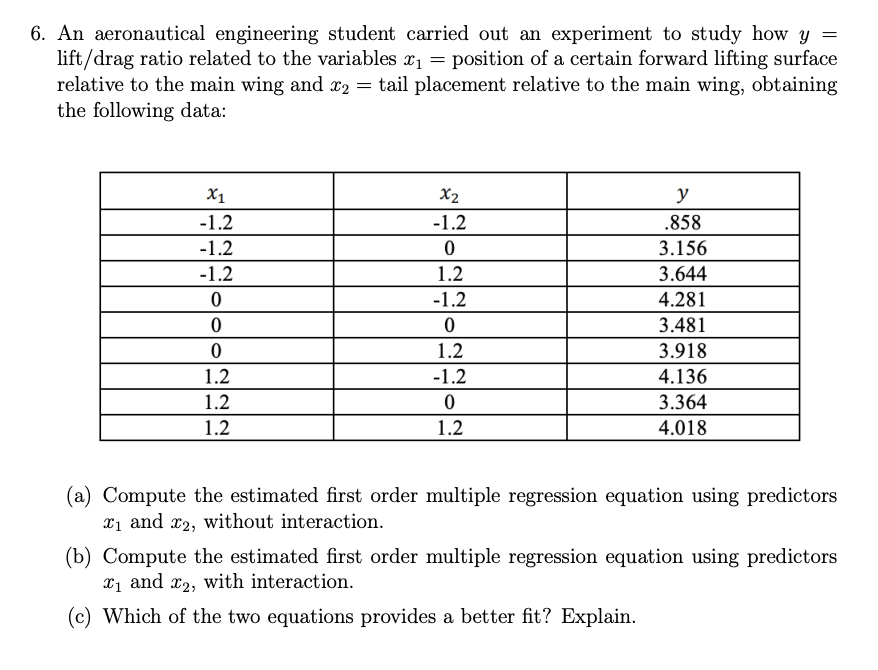

In [108]:
# Part a 
x1 <- c(-1.2, -1.2, -1.2, 0, 0, 0, 1.2, 1.2, 1.2)  # Forward lifting surface position
x2 <- c(-1.2, 0, 1.2, -1.2, 0, 1.2, -1.2, 0, 1.2)  # Tail placement position
y <- c(0.858, 3.156, 3.644, 4.281, 3.481, 3.918, 4.136, 3.364, 4.018)  # Lift/drag ratio
aero_data <- data.frame(
    x1 = x1,  
    x2 = x2,  
    y = y     
)
model_no_interaction <- lm(y ~ x1 + x2, data = aero_data)

coef_no_int <- coef(model_no_interaction)
beta_0_no_int <- coef_no_int[1]  # Intercept
beta_1_no_int <- coef_no_int[2]  # Coefficient for x₁
beta_2_no_int <- coef_no_int[3]  # Coefficient for x₂
cat("ŷ = B0 + B1x1 + B2x2\n")
cat("ŷ =", round(beta_0_no_int, 6), "+", round(beta_1_no_int, 6), "x₁ +", round(beta_2_no_int, 6), "x₂\n\n")

ŷ = B0 + B1x1 + B2x2
ŷ = 3.428444 + 0.536111 x₁ + 0.320139 x₂



In [109]:
# Part b 
model_with_interaction <- lm(y ~ x1 + x2 + x1:x2, data = aero_data)
coef_with_int <- coef(model_with_interaction)
beta_0_with_int <- coef_with_int[1]  # Intercept
beta_1_with_int <- coef_with_int[2]  # Coefficient for x₁
beta_2_with_int <- coef_with_int[3]  # Coefficient for x₂
beta_3_with_int <- coef_with_int[4]  # Interaction coefficient
cat("ŷ = B0 + B1x1 + B2x2 + B3x1x2\n")
cat("ŷ =", round(beta_0_with_int, 6), "+", round(beta_1_with_int, 6), "x1 +", round(beta_2_with_int, 6), "x2 +", round(beta_3_with_int, 6), "x1x2\n\n")

ŷ = B0 + B1x1 + B2x2 + B3x1x2
ŷ = 3.428444 + 0.536111 x1 + 0.320139 x2 + -0.504167 x1x2



In [79]:
# Part c 
summary(model_no_interaction)
summary(model_with_interaction)


Call:
lm(formula = y ~ x1 + x2, data = aero_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.5429 -0.4379  0.1054  0.4484  1.2367 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   3.4284     0.3097  11.069 3.24e-05 ***
x1            0.5361     0.3161   1.696    0.141    
x2            0.3201     0.3161   1.013    0.350    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.9292 on 6 degrees of freedom
Multiple R-squared:  0.394,	Adjusted R-squared:  0.192 
F-statistic: 1.951 on 2 and 6 DF,  p-value: 0.2225



Call:
lm(formula = y ~ x1 + x2 + x1:x2, data = aero_data)

Residuals:
       1        2        3        4        5        6        7        8 
-0.81694  0.37089 -0.25128  1.23672  0.05256  0.10539 -0.27761 -0.70778 
       9 
 0.28806 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   3.4284     0.2613  13.121 4.59e-05 ***
x1            0.5361     0.2667   2.010    0.101    
x2            0.3201     0.2667   1.200    0.284    
x1:x2        -0.5042     0.2722  -1.852    0.123    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.7839 on 5 degrees of freedom
Multiple R-squared:  0.6406,	Adjusted R-squared:  0.425 
F-statistic: 2.971 on 3 and 5 DF,  p-value: 0.1358


- The equation that provides a better fit is the second model (with interactions) due to its higher multiple R-squared, adjusted R-squared, F-stat, and lower residual standard error 